# QC of diaPASEF data generated

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from biorun.utils import Fasta
from setuptools.command.bdist_egg import make_zipfile

from src.QC import *
from src.plotting_functions import *
from src.filters import *
from src.column_spec import *

# pio.renderers.default = "png"


In [2]:
# df = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260818_peptide_MS2quant_None_transformed_limma_phPlus.tsv", sep="\t", low_memory=False)
# df = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260819_peptide_MS2quant_Norm_preprocessed.tsv", sep="\t", low_memory=False)
# df_batch_log2 = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260824_peptide_MS2quant_None_renamed_batchcorrected.tsv", sep="\t", low_memory=False)
df_batch = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv", sep="\t", low_memory=False)
# df.head(5)

In [3]:
CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A",] # MIX
CL_SELECTION = ["WT"]
CONDITION = ["_EGF_"]
DATA_TYPE = "raw:abs"

## Missingness

(<Figure size 1350x500 with 1 Axes>,
 <Axes: title={'center': "Missing values per sample - ['WT']"}, xlabel='Sample', ylabel='% missing // zero values'>)

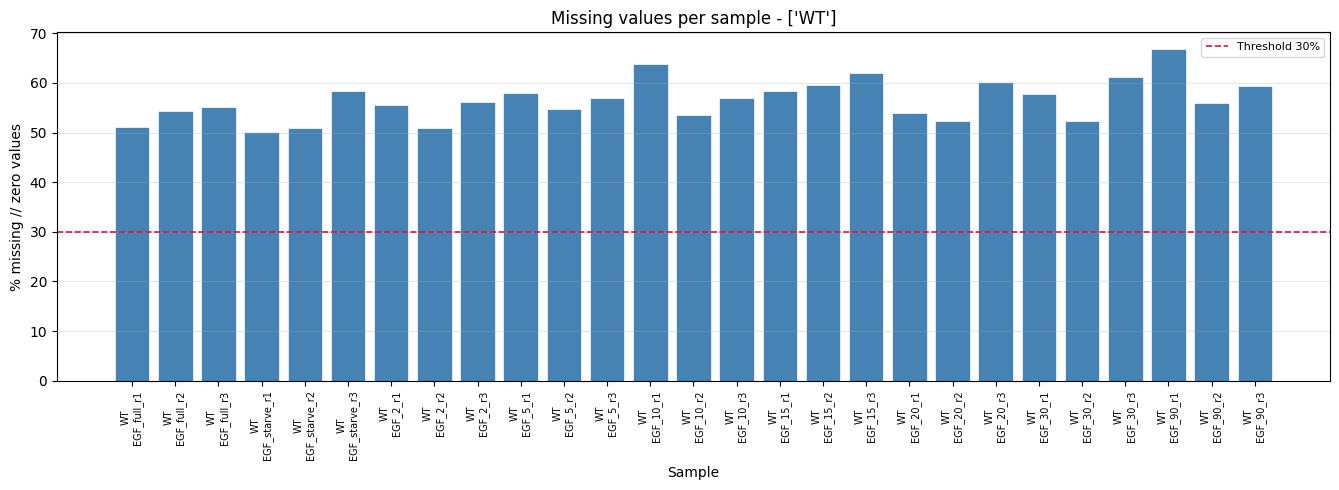

In [9]:
missing_values_per_sample(df,
                         cell_lines=CL_SELECTION,
                         conditions=["_EGF_"],
                         data_type = DATA_TYPE,
                         missing_threshold=0.30,
                         figsize=None,
                         title= f"Missing values per sample - {CL_SELECTION}",
                         ax=None,
)

(<Figure size 1350x500 with 1 Axes>,
 <Axes: title={'center': "Detected peptides per sample - ['WT']"}, xlabel='Sample', ylabel='Number of detected peptides'>)

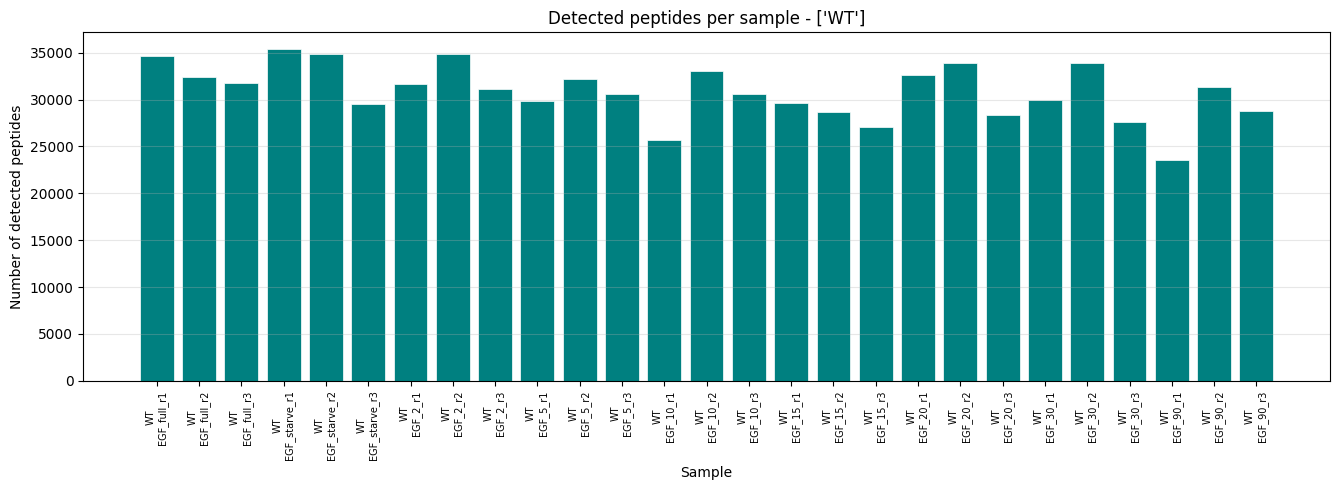

In [10]:
peptide_count_per_sample(df,
                         cell_lines = CL_SELECTION,
                         conditions = CONDITION,
                         data_type = DATA_TYPE,
                         missing_value=0.0,
                         figsize = None,
                         title = f"Detected peptides per sample - {CL_SELECTION}",
                         ax = None,
)

## Replicate coverage / counts

How many sites are actually usable for a time course? A site is only usable if it was measured
at **every** timepoint — but the replicate that saw it does not have to be the same one each time.
A site detected in (r1, r3) at 2 min and in (r2, r3) at 5 min is covered by 2 replicates at both
timepoints, so its **coverage depth** over that time course is 2.

Depth is therefore the *minimum* per-timepoint replicate count over the timepoints of a sample group,
and the depth of a **combination** of cell lines is the minimum over all of them: a site is only
usable for a comparison if every cell line in that comparison measured it at every timepoint.
Combining cell lines can only lower the depth, never raise it.

Sites are keyed on the first of `site`, `site_index`, `peptide_index`, `Index` present in the table
(so `site`, built in the cell above), or on `df.index` if none of them exist. Pass `site_col=` to
`replicate_coverage_matrix` to choose a different one.

| function (`src/QC.py`) | what it answers |
|---|---|
| `replicate_coverage_matrix` | replicates per site per cell line × condition × timepoint (raw material) |
| `replicate_coverage_depth` | depth per site per cell line, or per combination of cell lines |
| `coverage_summary` | how many sites reach ≥1, ≥2, ≥3 replicates |
| `plot_replicate_coverage` | the same as a grouped bar chart |
| `coverage_per_timepoint` / `plot_coverage_per_timepoint` | *which* timepoint is the bottleneck |
| `sites_with_coverage` | the site keys themselves |
| `filter_by_coverage` | the DataFrame subset to those sites |

In [11]:
# Replicates per site, per cell line x condition x timepoint. This is the raw material for everything below — nothing has been reduced yet.
# Sites are keyed on the "Index" column; cell lines / conditions / timepoints are auto-detected from the column names when left as None. Use exclude_full / exclude_starve / timepoints=[...] to leave the controls (or any run) out of the minimum.
coverage_matrix = replicate_coverage_matrix(df,
                                            cell_lines=None,
                                            conditions=CONDITION,
                                            data_type=DATA_TYPE,
                                            timepoints=None,
                                            exclude_full=False,
                                            exclude_starve=False,
                                            missing_value=0.0,
                                            site_col= "site")
print(coverage_matrix.shape)
coverage_matrix.head()

(71087, 73)


cell_line                                            WT                        \
condition                                           EGF                         
timepoint                                          full starve  2  5 10 15 20   
site                                                                            
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDSPL...    2      3  3  3  3  3  0   
Q9Y618_1595_1611_1_0~EIAKSPHSTVPEHHPHPISPYEHLLR...    2      3  1  2  1  0  2   
Q9H2G2_565_571_2_2_S565T569~VDEDSAEDTQSNDGK;VDE...    2      1  2  0  1  1  0   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGSFHTEAAR     0      0  1  0  1  0  1   
P08670_412_420_1_1_S419~ISLPLPNFSSLNLR                2      2  3  2  3  2  3   

cell_line                                                EGFRT693A  ...  \
condition                                                      EGF  ...   
timepoint                                          30 90      full  ...   
site                                                                ...   
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDSPL...  2  2         3  ...   
Q9Y618_1595_1611_1_0~EIAKSPHSTVPEHHPHPISPYEHLLR...  1  1         2  ...   
Q9H2G2_565_571_2_2_S565T569~VDEDSAEDTQSNDGK;VDE...  1  1         1  ...   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGSFHTEAAR   0  1         0  ...   
P08670_412_420_1_1_S419~ISLPLPNFSSLNLR              3  0         2  ...   

cell_line                                          RPS6KA3S375A               \
condition                                                   EGF                
timepoint                                                  full starve  2  5   
site                                                                           
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDSPL...            2      2  2  1   
Q9Y618_1595_1611_1_0~EIAKSPHSTVPEHHPHPISPYEHLLR...            2      2  3  2   
Q9H2G2_565_571_2_2_S565T569~VDEDSAEDTQSNDGK;VDE...            1      1  0  1   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGSFHTEAAR             2      2  2  0   
P08670_412_420_1_1_S419~ISLPLPNFSSLNLR                        1      3  1  2   

cell_line                                                            MIX  
condition                                                            EGF  
timepoint                                          10 15 20 30 90 starve  
site                                                                      
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDSPL...  2  3  2  2  1      3  
Q9Y618_1595_1611_1_0~EIAKSPHSTVPEHHPHPISPYEHLLR...  2  1  2  2  3      2  
Q9H2G2_565_571_2_2_S565T569~VDEDSAEDTQSNDGK;VDE...  1  1  2  1  1      2  
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGSFHTEAAR   1  1  1  0  1      1  
P08670_412_420_1_1_S419~ISLPLPNFSSLNLR              0  2  2  2  2      3  

[5 rows x 73 columns]

### Check number of counts of a site per cell_line and within groups

Replicate coverage per timepoint (71087 sites total):
  WT                   ≥1 rep : 23175 (32.6%) | ≥2 reps: 10700 (15.1%) | ≥3 reps: 4972 (7.0%)
  EGFRT693A            ≥1 rep : 22873 (32.2%) | ≥2 reps: 10480 (14.7%) | ≥3 reps: 4937 (6.9%)
  BRAFS151A1           ≥1 rep : 23317 (32.8%) | ≥2 reps: 10555 (14.8%) | ≥3 reps: 4261 (6.0%)
  SOS1S1178A           ≥1 rep : 24158 (34.0%) | ≥2 reps: 11099 (15.6%) | ≥3 reps: 4332 (6.1%)
  SHOC2T71A            ≥1 rep : 23555 (33.1%) | ≥2 reps: 10597 (14.9%) | ≥3 reps: 361 (0.5%)
  BRAFS151A2           ≥1 rep : 24676 (34.7%) | ≥2 reps: 11738 (16.5%) | ≥3 reps: 5485 (7.7%)
  GAB1Y259A            ≥1 rep : 25092 (35.3%) | ≥2 reps: 11840 (16.7%) | ≥3 reps: 5503 (7.7%)
  RPS6KA3S375A         ≥1 rep : 23348 (32.8%) | ≥2 reps: 10662 (15.0%) | ≥3 reps: 5127 (7.2%)
  MIX                  ≥1 rep : 49137 (69.1%) | ≥2 reps: 32092 (45.1%) | ≥3 reps: 16954 (23.8%)
  ALL                  ≥1 rep : 11372 (16.0%) | ≥2 reps: 5783 (8.1%) | ≥3 reps: 243 (0.3%)


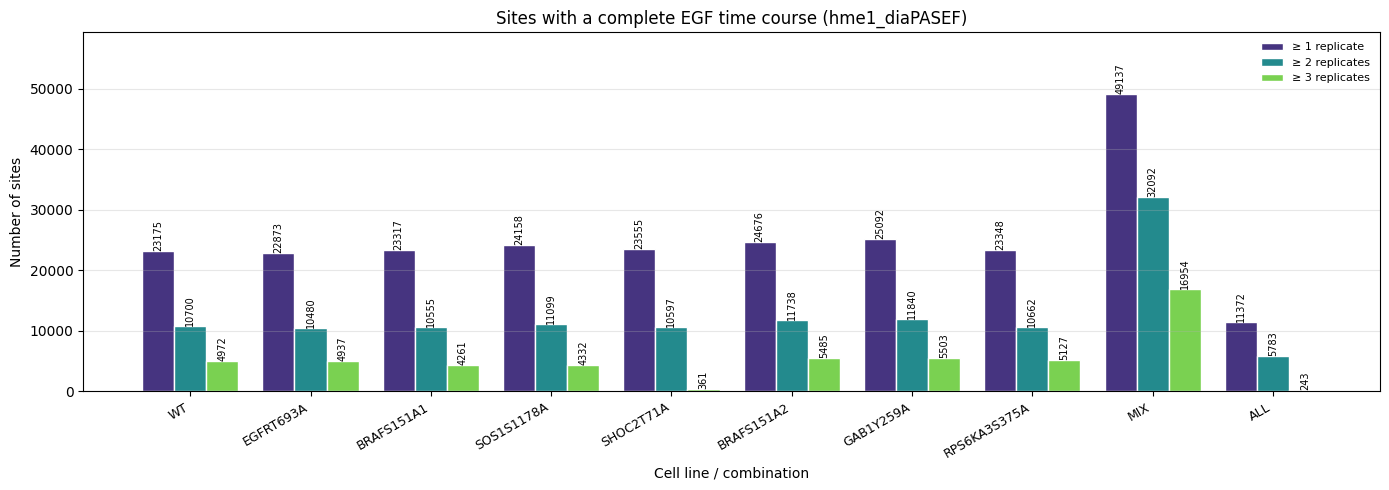

In [12]:
GROUPS = {}

# One column per cell line, plus an "ALL" group: sites with a complete time course in every cell line at the same time.
depth = replicate_coverage_depth(counts = coverage_matrix,
                                 groups = None,
                                 include_all=True,) # Returns the coverage per site per cell line.

# For grouping here, you have to define and calculate the groups for the replicate_coverage_depth()
coverage_table = coverage_summary(depth = depth,
                                  max_depth= None,
                                  print_summary = True,)
coverage_df, coverage_fig, ax = plot_replicate_coverage(depth = depth,
                                       max_depth = None,
                                       as_percent= False,
                                       title="Sites with a complete EGF time course (hme1_diaPASEF)",)


### What is the coverage across time points?

These are the number of phospho-peptides that have "n" coverage at each time point. DO NOT GET CONFUSED: phosphopeptides can 3 replicates at several time points and still have missingness in other time points, this is why here the counts of phosphopeptides with 3 replicates per time point is higher than for the graph above.

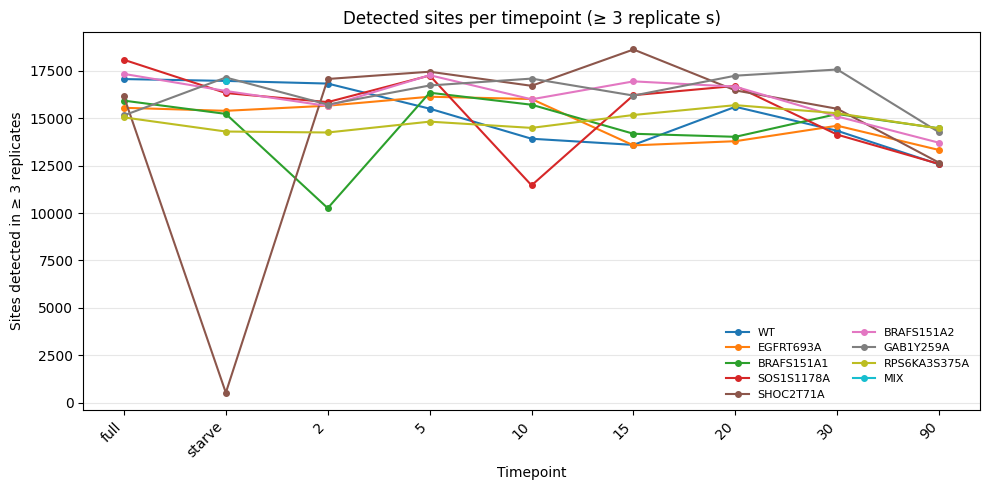

In [13]:
cpt_df = coverage_per_timepoint(counts = coverage_matrix,
                           max_depth = 3,
                           print_summary = False,)
table, fig, ax = plot_coverage_per_timepoint(counts= coverage_matrix,
                                min_reps=3,
                                title=None,)

## Filtering based on coverage

`sites_with_coverage` returns the site keys, so any of the groups above can be turned into a row
filter for the rest of the preprocessing (fold changes, clustering, mutant comparison).

In [14]:
group = "WT"
WT_f_df = filter_by_coverage(df = df,
                                depth = depth,
                                group=group,
                                min_reps=2,)
print(f"key column: {depth.index.name}")
print(f"{len(WT_f_df)} of {len(df)} sites covered in >= 2 replicates at every timepoint in {group}")
WT_f_df

key column: site
10700 of 71087 sites covered in >= 2 replicates at every timepoint in WT


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
9,P0DMV8_362_371_1_1_S362,HSPA1A,P0DMV8,DLNKSINPDEAVAYGAAVQAAILMGDK,LQDFFNGR.DLNKSINPDEAVAYGAAVQAAILMGDK.SENVQDLL,358,384,27,1.0000,P0DMV8,...,NaN,NaN,NaN,0.452000,False,NaN,NaN,NaN,NaN,NaN
12,Q96RK0_2306_2318_1_1_S2318,CIC,Q96RK0,NSTDLDSAPEDPTSPKR;RKNSTDLDSAPEDPTSPK;KNSTDLDSA...,GSYRKKRK.NSTDLDSAPEDPTSPK.RKMRRRSS,2305,2320,16,1.0000,Q96RK0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,P35269_385_400_1_1_T389,GTF2F1,P35269,GNSRPGTPSAEGGSTSSTLR,KPSGGSSR.GNSRPGTPSAEGGSTSSTLR.AAASKLEQ,383,402,20,1.0000,P35269,...,NaN,NaN,NaN,0.772932,True,human,"activity, inhibited","transcription, inhibited",NaN,NaN
26,Q71RC2_717_722_1_1_S722,LARP4,Q71RC2,EQYVPPRSPK;NGKEQYVPPRSPK,GVTRRNGK.EQYVPPRSPK.-,715,724,10,1.0000,Q71RC2,...,NaN,NaN,NaN,0.690329,True,NaN,NaN,NaN,NaN,NaN
32,Q9HD20_899_905_1_1_S899,ATP13A1,Q9HD20,DSPTLSNSGIR;RPRDSPTLSNSGIR,VERRRRPR.DSPTLSNSGIR.ATSRTAKQ,898,908,11,1.0000,Q9HD20,...,NaN,NaN,NaN,0.405902,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71055,P15336_253_272_1_0,ATF2,P15336,PVTMVPSVPGIPGPSSPQPVQSEAK,PAAVPLVR.PVTMVPSVPGIPGPSSPQPVQSEAK.MRLKAALT,251,275,25,1.0000,P15336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71068,Q9HCK8_1993_2023_2_2_S1995S2008,CHD8,Q9HCK8,TASPLPLRPDAPVEKSPEETATQVPSLESLTLK,LHQQYTSR.TASPLPLRPDAPVEKSPEETATQVPSLESLTLK.LEH...,1993,2025,33,1.0000,Q9HCK8,...,NaN,NaN,NaN,0.431316,True|True,NaN,NaN,NaN,NaN,NaN
71070,P35568_1000_1012_1_1_S1005,IRS1,P35568,QSYVDTSPAAPVSYADMR,TMQMSCPR.QSYVDTSPAAPVSYADMR.TGIAAEEV,999,1016,18,1.0000,P35568,...,NaN,NaN,NaN,0.284332,True,NaN,NaN,NaN,NaN,NaN
71082,Q13112_507_538_1_1_S538,CHAF1B,Q13112,TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELKR;TDTPPSS...,RINLTPLK.TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELK...,507,543,37,1.0000,Q13112,...,NaN,NaN,NaN,0.538663,True,NaN,NaN,NaN,NaN,NaN


### For how many of the sites a time point has been detected in at least 2 sites (the starve and another one)

In [15]:
for cell in CELL_LINES:
    fc_cols = ColumnSpec.select(df = df,
                                cell_lines = [cell],
                                data_type = "log2:FC",
                                conditions=["_EGF_"])
    n_any = int(df[fc_cols].notna().any(axis=1).sum()) # columns for which there is no time point with FC bigger than fc_filter
    n_all = int(df[fc_cols].notna().all(axis=1).sum()) # columns with at least one time point with FC bigger than fc_filter
    print(f"{cell:<14} FC at >=1 timepoint: {n_any:>6} | at every timepoint: {n_all:>6} | of {len(df)}")


WT             FC at >=1 timepoint:  50250 | at every timepoint:  23175 | of 71087
EGFRT693A      FC at >=1 timepoint:  48291 | at every timepoint:  22873 | of 71087
BRAFS151A1     FC at >=1 timepoint:  49241 | at every timepoint:  23317 | of 71087
SOS1S1178A     FC at >=1 timepoint:  48541 | at every timepoint:  24158 | of 71087
SHOC2T71A      FC at >=1 timepoint:  43467 | at every timepoint:  23555 | of 71087
BRAFS151A2     FC at >=1 timepoint:  48828 | at every timepoint:  24676 | of 71087
GAB1Y259A      FC at >=1 timepoint:  50564 | at every timepoint:  25092 | of 71087
RPS6KA3S375A   FC at >=1 timepoint:  47415 | at every timepoint:  23348 | of 71087
MIX            FC at >=1 timepoint:      0 | at every timepoint:  71087 | of 71087


## Missingness

(<Figure size 1350x1000 with 1 Axes>,
 <Axes: title={'center': 'Replicate detection map'}, ylabel='71087 sites'>)

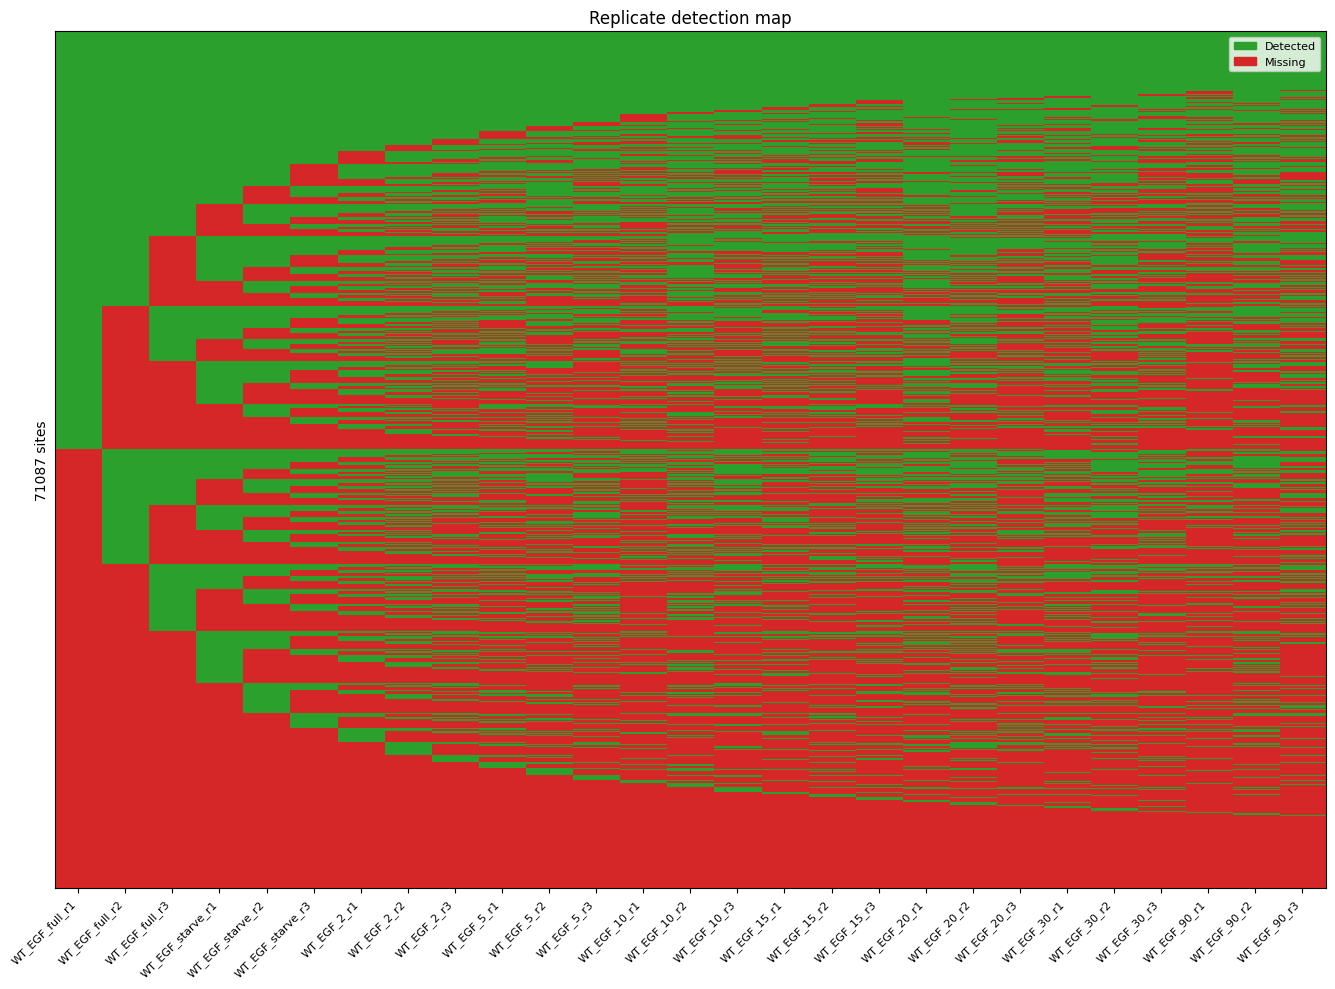

In [16]:
replicate_detection_map(
    df,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="log2:abs",
    missing_value=0.0,
    figsize=None,
    title="Replicate detection map",
    ax=None,
)

## Localization completenes


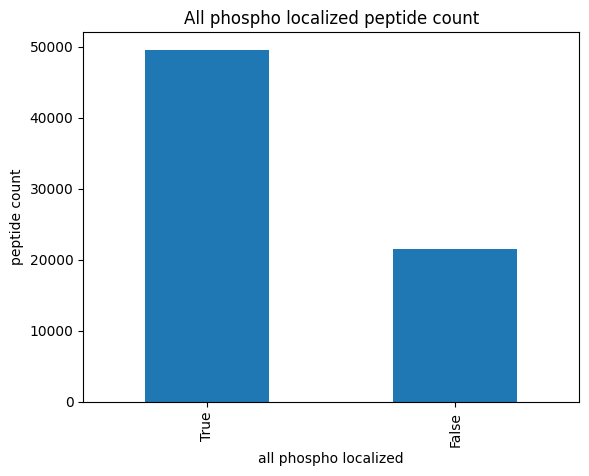

In [17]:
df['total_phospho'] = df["peptide_index"].str.split("_").str[3]
df["localized_phospho"] = df["peptide_index"].str.split("_").str[4]
df['all_phospho_localized'] = df['total_phospho'] == df["localized_phospho"]

df['all_phospho_localized'].value_counts().plot(kind='bar')
plt.xlabel('all phospho localized')
plt.ylabel('peptide count')
plt.title('All phospho localized peptide count')
plt.show()

## Intensity distribution

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Intensity distribution per sample'}, xlabel='log2 intensity', ylabel='Density'>)

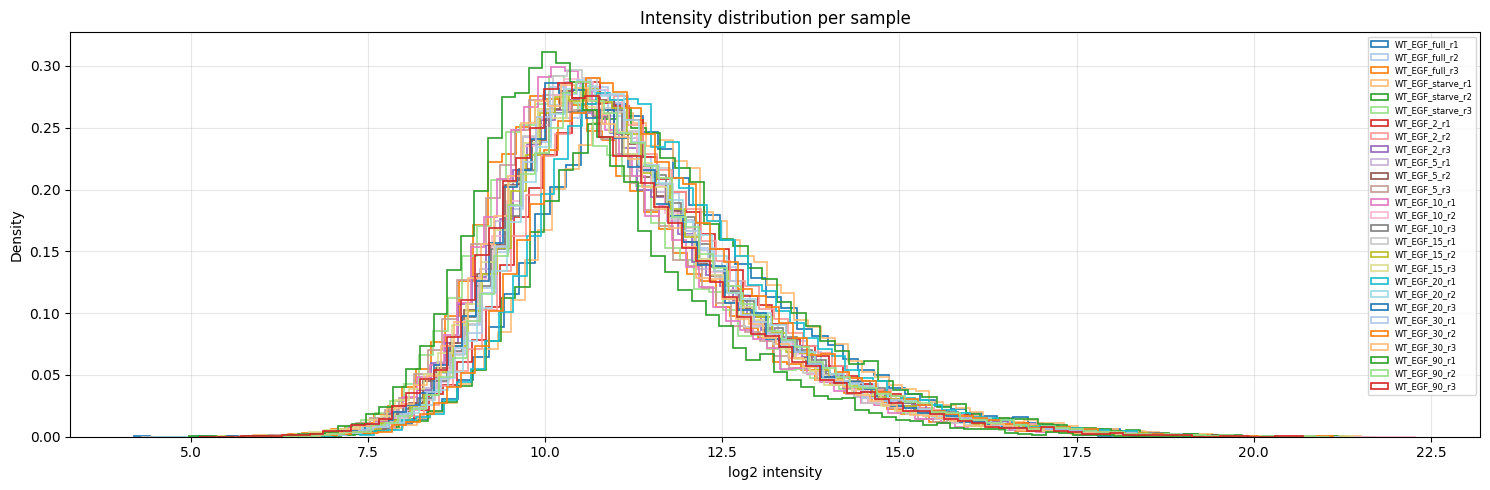

In [19]:
intensity_distribution(df,
                       cell_lines=CL_SELECTION,
                       conditions=["_EGF_"],
                       data_type="log2:abs",
                       log_transform= False,
                       figsize=(15,5),
                       title="Intensity distribution per sample",
                       ax=None,
)

## CV variance

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/QC.py:1349: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'CV distribution per timepoint'}, xlabel='Condition / timepoint', ylabel='CV (%)'>)

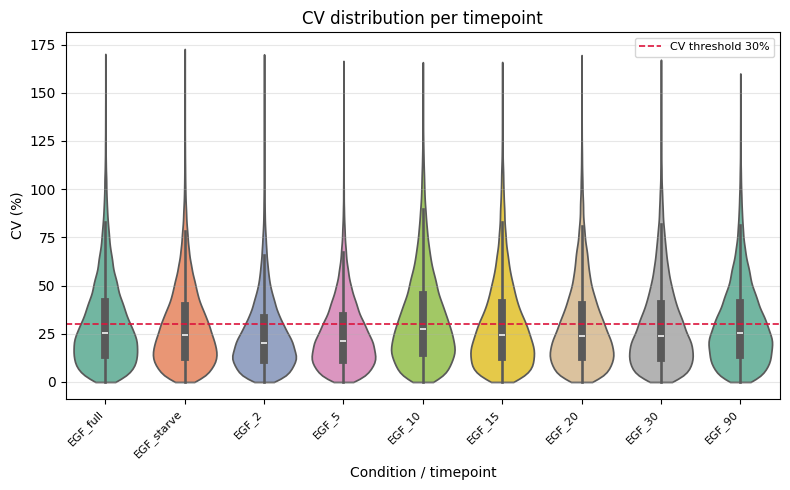

In [88]:
# CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A",] # MIX
cv_distribution(df,
                cell_lines=["WT"],
                conditions=["_EGF_"],
                data_type="raw:cv",
                cv_threshold=30.0,
                figsize=None,
                title="CV distribution per timepoint",
                ax=None,
)

## PCA

### Filter based on cell line and depth

In [21]:
group = "WT"
WT_f_df = filter_by_coverage(df = df,
                                depth = depth,
                                group=group,
                                min_reps=2,)
print(f"key column: {depth.index.name}")
print(f"{len(WT_f_df)} of {len(df)} sites covered in >= 2 replicates at every timepoint in {group}")
WT_f_df

key column: site
10700 of 71087 sites covered in >= 2 replicates at every timepoint in WT


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT,total_phospho,localized_phospho,all_phospho_localized
9,P0DMV8_362_371_1_1_S362,HSPA1A,P0DMV8,DLNKSINPDEAVAYGAAVQAAILMGDK,LQDFFNGR.DLNKSINPDEAVAYGAAVQAAILMGDK.SENVQDLL,358,384,27,1.0000,P0DMV8,...,0.452000,False,NaN,NaN,NaN,NaN,NaN,1,1,True
12,Q96RK0_2306_2318_1_1_S2318,CIC,Q96RK0,NSTDLDSAPEDPTSPKR;RKNSTDLDSAPEDPTSPK;KNSTDLDSA...,GSYRKKRK.NSTDLDSAPEDPTSPK.RKMRRRSS,2305,2320,16,1.0000,Q96RK0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,True
24,P35269_385_400_1_1_T389,GTF2F1,P35269,GNSRPGTPSAEGGSTSSTLR,KPSGGSSR.GNSRPGTPSAEGGSTSSTLR.AAASKLEQ,383,402,20,1.0000,P35269,...,0.772932,True,human,"activity, inhibited","transcription, inhibited",NaN,NaN,1,1,True
26,Q71RC2_717_722_1_1_S722,LARP4,Q71RC2,EQYVPPRSPK;NGKEQYVPPRSPK,GVTRRNGK.EQYVPPRSPK.-,715,724,10,1.0000,Q71RC2,...,0.690329,True,NaN,NaN,NaN,NaN,NaN,1,1,True
32,Q9HD20_899_905_1_1_S899,ATP13A1,Q9HD20,DSPTLSNSGIR;RPRDSPTLSNSGIR,VERRRRPR.DSPTLSNSGIR.ATSRTAKQ,898,908,11,1.0000,Q9HD20,...,0.405902,True,NaN,NaN,NaN,NaN,NaN,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71055,P15336_253_272_1_0,ATF2,P15336,PVTMVPSVPGIPGPSSPQPVQSEAK,PAAVPLVR.PVTMVPSVPGIPGPSSPQPVQSEAK.MRLKAALT,251,275,25,1.0000,P15336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,False
71068,Q9HCK8_1993_2023_2_2_S1995S2008,CHD8,Q9HCK8,TASPLPLRPDAPVEKSPEETATQVPSLESLTLK,LHQQYTSR.TASPLPLRPDAPVEKSPEETATQVPSLESLTLK.LEH...,1993,2025,33,1.0000,Q9HCK8,...,0.431316,True|True,NaN,NaN,NaN,NaN,NaN,2,2,True
71070,P35568_1000_1012_1_1_S1005,IRS1,P35568,QSYVDTSPAAPVSYADMR,TMQMSCPR.QSYVDTSPAAPVSYADMR.TGIAAEEV,999,1016,18,1.0000,P35568,...,0.284332,True,NaN,NaN,NaN,NaN,NaN,1,1,True
71082,Q13112_507_538_1_1_S538,CHAF1B,Q13112,TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELKR;TDTPPSS...,RINLTPLK.TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELK...,507,543,37,1.0000,Q13112,...,0.538663,True,NaN,NaN,NaN,NaN,NaN,1,1,True


#### Filter based on representatice proteins of the pathway

In [25]:
signor = pd.read_csv("../../External_Data/Metadata/Signor/SIGNOR-EGF_14_08_26.tsv", sep="\t", low_memory=False)
signor_proteins = set(signor["IDA"].to_list() + signor["IDB"].to_list()) # ENTITYA  ENTITYB
signor_proteins = [element for element in signor_proteins if "SIGNOR" not in element and "CHEBI" not in element]
print(f"Number of proteins selected with SIGNOR: {len(signor_proteins)}")

reactome_EGFR= pd.read_csv("../../External_Data/Metadata/Reactome/EGFR_signaling_proteins_reactome.tsv", sep="\t", low_memory=False)
reactome_proteins = reactome_EGFR["Identifier"].to_list()
print(f"Number of proteins selected with REACTOME: {len(reactome_proteins)}")

string_MAPK = pd.read_csv("../../External_Data/Metadata/String/MAPK_signaling_cascades_string_interactions.tsv", sep="\t", low_memory=False)
string_proteins = set(string_MAPK["#node1"].to_list() + string_MAPK["node2"].to_list())
print(f"Number of proteins selected with STRING: {len(string_proteins)}")


Number of proteins selected with SIGNOR: 25
Number of proteins selected with REACTOME: 55
Number of proteins selected with STRING: 322


In [29]:
sub_df = WT_f_df.loc[WT_f_df["protein_name"].isin(string_proteins)].copy()
sub_df

,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT,total_phospho,localized_phospho,all_phospho_localized
441,P29353_139_145_1_1_S139,SHC1,P29353,HGSFVNKPTR,LGGEEWTR.HGSFVNKPTR.GWLHPNDK,137,146,10,1.0,P29353,...,0.593201,False,human,NaN,"apoptosis, induced",NaN,NaN,1,1,True
983,O00231_14_18_1_0,PSMD11,O00231,AAAAVVEFQRAQSLLSTDR;AQSLLSTDR,M.AAAAVVEFQRAQSLLSTDR.EASIDILH,2,20,19,1.0,O00231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,False
1476,P25789_75_87_1_1_S75,PSMA4,P25789,LNEDMACSVAGITSDANVLTNELR,FFSEKIYK.LNEDMACSVAGITSDANVLTNELR.LIAQRYLL,68,91,24,1.0,P25789,...,NaN,False,NaN,NaN,NaN,NaN,NaN,1,1,True
1781,P00533_1162_1172_1_1_S1166,EGFR,P00533,GSHQISLDNPDYQQDFFPK,SPAHWAQK.GSHQISLDNPDYQQDFFPK.EAKPNGIF,1161,1179,19,1.0,P00533,...,0.586968,False,NaN,NaN,NaN,NaN,NaN,1,1,True
1871,O43524_299_307_1_1_S299,FOXO3,O43524,SSDELDAWTDFR,WPGSPTSR.SSDELDAWTDFR.SRTNSNAS,299,310,12,1.0,O43524,...,0.443486,False,NaN,NaN,NaN,NaN,NaN,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70522,P35568_3_11_1_0,IRS1,P35568,ASPPESDGFSDVRK;ASPPESDGFSDVR,M.ASPPESDGFSDVRK.VGYLRKPK,2,15,14,1.0,P35568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,False
70852,Q01082_2328_2341_1_1_S2341,SPTBN1,Q01082,AQTLPTSVVTITSESSPGKR;AQTLPTSVVTITSESSPGK,QSTPASSR.AQTLPTSVVTITSESSPGKR.EKDKEKDK,2326,2345,20,1.0,Q01082,...,0.547307,True,NaN,NaN,NaN,NaN,NaN,1,1,True
70853,Q01082_2328_2341_1_1_S2340,SPTBN1,Q01082,AQTLPTSVVTITSESSPGKR;AQTLPTSVVTITSESSPGK,QSTPASSR.AQTLPTSVVTITSESSPGKR.EKDKEKDK,2326,2345,20,1.0,Q01082,...,0.473610,False,NaN,NaN,NaN,NaN,NaN,1,1,True
70926,Q9Y4H2_1109_1124_1_1_S1115,IRS2,Q9Y4H2,RLSLMEQVSGVEAFLQASQPPDPHR,ASPTSGVK.RLSLMEQVSGVEAFLQASQPPDPHR.GAKVIRAD,1107,1131,25,1.0,Q9Y4H2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,True


In [63]:
fig_scatter, fig_variance, pca_df = pca_plot_interactive(
                                                        df_batch,
                                                        cell_lines= CELL_LINES,
                                                        conditions=["_EGF_"],
                                                        data_type="raw:abs",
                                                        n_components=5,
                                                        impute=True,
                                                        impute_method="mean",
                                                        color_by="cell_line", #condition  cell_line
                                                        figsize=(700, 600), #(1000, 800)
                                                        title="PCA of replicate samples - batch corrected",
                                                    )
fig_scatter.show()

## PCA of condition centroids

One point per `(cell_line, condition, timepoint)` group instead of one per replicate, so the
biological trajectory is readable when the replicate-level plot above is too crowded.

**`centroid_space` decides where the averaging happens, and the two are different plots.**

| | `"pca"` (default) | `"data"` |
|---|---|---|
| what is averaged | the replicates' **PC coordinates** | the replicates' **intensities**, before the PCA |
| embedding | **identical** to the PCA above — axes and % variance are directly comparable | a **new** PCA on the group matrix; loadings, axes and % variance all change |
| replicate spread | survives, drawn as the error bars | gone — averaged away before the fit |
| sites kept | only sites complete in **every replicate** | sites complete in **every group** |

That last row is not a detail on this data: on hme1_2 the replicate-level PCA keeps
**2896 / 8723** sites, the group-level one keeps **8723 / 8723** — a site missing in one replicate
still has a group mean. So `"data"` is fitted on ~3× more sites, which is a real argument for it,
paid for by losing comparability with the plot above.

⚠️ **Averaging always makes separation look cleaner than it is.** A centroid plot cannot tell you
whether groups are separated *relative to replicate scatter* — that is exactly the information
averaging removes. Read the error bars before believing a separation: if they overlap, the groups
are not resolved no matter how far apart the centroids sit. When the question is replicate
agreement or outlier detection, use the replicate-level PCA above, not this one.


In [78]:
# Centroid PCA — one point per cell line x timepoint instead of one per injection.
fig_scatter, fig_variance, centroid_df = pca_centroid_plot_interactive(
                                                        sub_df, #sub_df,df_batch
                                                        cell_lines=["WT"],
                                                        conditions=["_EGF_"],
                                                        data_type="raw:abs",
                                                        n_components=5,
                                                        impute=True,
                                                        impute_method="mean",
                                                        centroid_space="pca",   # "pca" | "data"
                                                        centroid_stat="mean",   # "mean" | "median"
                                                        color_by="condition",   # condition | cell_line
                                                        symbol_by="cell_line",
                                                        error_bars="sd",        # "sd" | "sem" | None
                                                        show_replicates=True,   # faint replicate cloud behind
                                                        figsize=(900, 700),
                                                        title="PCA of condition centroids - String proteins - 274 sites",
                                                    )
fig_scatter.show()

centroid_df[["group", "cell_line", "timepoint", "n_reps", "PC1", "PC2", "PC1_sd", "PC2_sd"]]


,group,cell_line,timepoint,n_reps,PC1,PC2,PC1_sd,PC2_sd
0,WT_EGF_full,WT,full,3,7.736266,5.129777,15.488159,4.994708
1,WT_EGF_starve,WT,starve,3,12.374616,-8.278844,19.343107,1.556084
2,WT_EGF_2,WT,2,3,3.381063,-6.648186,4.892311,0.838719
3,WT_EGF_5,WT,5,3,-3.789707,-3.173997,3.720700,2.009615
4,WT_EGF_10,WT,10,3,-4.556146,1.866679,7.241888,3.300056
5,WT_EGF_15,WT,15,3,-8.150015,4.489169,2.534887,2.223785
6,WT_EGF_20,WT,20,3,2.768361,5.714882,8.180842,3.618138
7,WT_EGF_30,WT,30,3,-1.715434,3.704432,8.320730,2.823872
8,WT_EGF_90,WT,90,3,-8.049003,-2.803912,11.865104,2.030825


### Why the PCA looks the same whatever sites you feed it

Both things you are seeing — timepoints not separating, and the plot not moving when you cut the site
list down to a hand-picked pathway set — are **one effect, and it is not a bug in
`pca_plot_interactive()`**. The function selects the replicate columns, imputes, drops sites not seen
in every run, standardises **per site** and runs PCA with samples as observations. All of that is
correct. The problem is what the data has most of.

#### PC1 is the per-run loading, not biology

`log2:abs` is un-normalised: FragPipe wrote it with normalisation `None`, and neither
`run_diapasef_transformations()` nor the PCA applies any between-run scaling. Every run therefore
carries its own overall intensity offset, and **that offset is added to every site of that run**.

Measured on the 200-row development sample (WT, `log2:abs`, the 65 sites that survive imputation +
`dropna`) — re-run these on the full table, the numbers will differ but the pattern will not:

| quantity | value | reading |
|---|---|---|
| `corr(PC1 scores, mean standardised value per run)` | **0.994** | PC1 *is* the per-run average |
| `corr(PC1 scores, per-run median log2 intensity)` | **0.961** | and that average is the run's loading |
| spread of per-run medians within WT | ≈ 1.5–2 log2 | 3–4× in linear intensity, between runs of the same cell line |
| median pairwise correlation between sites, across runs | **+0.27** | all sites move up and down together |

That last row is the whole story. A positive *average* correlation between features means the
site × site correlation matrix has one dominant eigenvector that is essentially the **equal-weight
average of all sites**. The sample scores on it are then just "the mean level of this run" — a
property of the **run**, not of the sites.

#### Why subsetting cannot change it

If PC1 is the equal-weight average over sites, then swapping in a different set of sites changes
almost nothing: you are averaging a different sample of columns that all contain the *same* per-run
offset. The average of 30 pathway sites and the average of 8000 sites estimate the same quantity —
the second is just a less noisy estimate of it. Adding more sites does not add resolution on biology;
it sharpens the estimate of the technical factor.

Measured, same sample — full site set versus a random subset small enough to be brutal (9 sites):

| PCA input | PC1 var | \|corr(PC1 full, PC1 subset)\| |
|---|---|---|
| as the notebook runs it (no between-run normalisation) | 34.2% | **0.93** |
| same data, each run's median subtracted first | 17.9% | **0.10** |

Removing the per-run median is the one change that makes the PCA depend on which sites you chose —
which is exactly the behaviour you expected and did not get. Note this is *not* something per-site
standardisation can do for you: `StandardScaler` centres each **site** across runs, which removes each
site's own baseline level, but an offset shared by every site of a run survives it untouched (it is a
row effect, and standardisation is a column operation).

#### Why the timepoints do not separate

Two reasons stack on top of each other:

1. **Scale.** The EGF response moves responsive sites by roughly 0.2–1 log2, while the run-to-run
   loading spread is 1.5–2 log2. The technical axis is bigger than the biological one, so it takes
   PC1 and PC2 before the timepoint structure gets a look in.
2. **Dilution.** PCA is unsupervised over whatever sites it is given, and most sites do not respond to
   EGF. Their run-to-run variation is noise plus loading, and it enters the covariance with the same
   weight as a real responder. This is the part your pathway subset was meant to fix — and it *would*
   help, but only after point 1 is dealt with, because right now the leading direction is the same for
   any subset.

A third, smaller factor specific to this dataset: `pca_plot_interactive()` imputes missing replicates
and then drops every site not observed in all 27 runs, so the PCA already runs on the complete-coverage
sites. Your SIGNOR filter selects *within* that set, so the site population it draws from is one that
was already homogeneous with respect to the shared factor.

#### How to confirm it on the full data (no code changed anywhere)

```python
cols = [c for c in ColumnSpec.select(df, cell_lines=["WT"], data_type="log2:abs",
                                     conditions=["_EGF_"]) if c.endswith(("_r1", "_r2", "_r3"))]
run_medians = df[cols].median()                       # one per run
print(run_medians.max() - run_medians.min())          # the loading spread, in log2
print(pca_df.set_index("sample")["PC1"].corr(run_medians))   # PC1 against it
```

If that correlation is high, PC1 is measuring sample loading. The fix is between-run normalisation
(median-centring or quantile) applied **before** the PCA — the same open decision recorded for the
`NORMALIZE` parameter in `limma_for_pvalues_diapasef.rmd`, and the same defect written up for the TMT
data in `clustering_method_decision.md` §1. Running the PCA on `log2:FC` instead of `log2:abs` helps
but does not settle it: a fold change cancels the site's baseline, not the difference between the
loading of the stimulated run and the loading of the starve run.

*(Numbers above come from the 200-row development sample, so treat them as the shape of the problem,
not as this dataset's values.)*

### …and why it *does* change once you use the FragPipe `Norm` output

This is the confirmation of the diagnosis above, not a new puzzle. The previous cell predicted exactly
this: *"removing the per-run median is the one change that makes the PCA depend on which sites you
chose"*. FragPipe's `Norm` output is that change, applied upstream — it equalises the runs before the
table ever reaches this notebook.

#### What normalisation removes

The un-normalised matrix is, to a good approximation, **biology + a per-run constant**. That constant
is the same number for every site in the run, so every site's profile across runs contains a copy of
the same run-level vector. That is what makes the sites correlate with each other, and a set of
mutually correlated features has one dominant direction — the equal-weight average — that *any*
subset reproduces.

Normalisation subtracts that constant. Once it is gone there is no longer a single direction hiding in
every site, so PC1 has to be assembled out of whatever covariance the sites you actually selected
happen to share. Different sites → different covariance → different plot. Measured on the development
sample (median-centring the runs, which is what FragPipe's median normalisation does):

| | un-normalised (`None`) | normalised |
|---|---|---|
| mean pairwise correlation between sites | **+0.27** | **+0.03** |
| PC1 / PC2 variance explained | 34.2% / 11.6% | 17.9% / 15.5% |
| \|corr(PC1 of a random 10-site subset, PC1 of all sites)\| | 0.91 ± 0.05 | 0.60 ± 0.24 |
| \|corr(PC1 of a random 30-site subset, PC1 of all sites)\| | 0.98 ± 0.01 | 0.75 ± 0.27 |

The mean inter-site correlation falling from +0.27 to +0.03 is the mechanism in one number: the sites
stop moving together. The flattening of the variance spectrum (a 34% PC1 becoming 18% / 15%) is the
same fact seen from the other side — the rank-1 technical factor that used to dominate is no longer
there, so the variance is spread across several comparable PCs.

#### ⚠️ The plot changing is not, by itself, evidence that your pathway sites found something

The same experiment, run as a control: take **two disjoint random subsets of 20 sites** — no pathway
logic, no overlap between them — and compare the PCA each one produces.

| | un-normalised | normalised |
|---|---|---|
| \|corr(PC1 subset A, PC1 subset B)\|, disjoint random sites | **0.90 ± 0.04** | **0.39 ± 0.23** |

Un-normalised, two unrelated site sets gave the *same* PCA (0.90) — which is the effect you were
seeing. Normalised, two unrelated site sets give *different* PCAs (0.39 ± 0.23). So after
normalisation, "the plot moves when I change the sites" is the **baseline behaviour of random sites**,
not a property of the SIGNOR selection. Two things contribute and they need separating:

1. **Signal** — the subset expresses its own covariance structure, which is what you wanted.
2. **Sampling noise** — with ~30 features and 27 samples, PCA is in the regime where the estimated
   components are genuinely unstable (hence the ±0.2–0.3 spread in the table above). Sign flips and
   reshuffled points between runs of the same analysis are expected here.

**The control that separates them:** compare the pathway subset against size-matched random subsets
drawn from the same filtered table. If the SIGNOR sites separate timepoints *more* than 50 random
subsets of the same size do, that is a real result. If they separate about as well, the change you are
seeing is dimensionality, not biology. The question to ask of the plot is not "did it change" but "do
replicates of one timepoint sit closer together than samples of different timepoints" — and that is
answerable with a number (between-timepoint spread ÷ within-replicate spread) rather than by eye.

#### Consequences for the rest of the pipeline

Switching input files changes the input to *everything* downstream, so keep it consistent:

- `run_diapasef_transformations()` applies no normalisation of its own by design, so whichever
  FragPipe output you feed it is what every `log2:FC`, `log2:scaled`, `log2:zscore` and `log2:step`
  column inherits.
- In `limma_for_pvalues_diapasef.rmd`, `NORMALIZE <- "none"` was flagged as an open decision precisely
  because the input was un-normalised. On a `Norm` input that setting becomes correct *because the
  normalisation already happened* — do not stack a second one on top without deciding to. The
  `per-run log2:abs medians: span …` line that notebook prints on load is the check: it should be much
  smaller on the `Norm` file.
- The `replicate effect` diagnostic in the same notebook should also shrink if the offsets were
  loading; whatever survives normalisation is batch structure that scaling cannot explain away.

*One honest caveat.* Median normalisation assumes most sites do not change between runs, so it cannot
distinguish "this run was loaded 1.5× heavier" from "EGF genuinely raised phosphorylation everywhere".
Without a spike-in or total-protein anchor that distinction is not identifiable, and the standard
assumption — that responders are a minority of the phosphoproteome, so the median is set by
non-responders — is the one being made here. It is a reasonable assumption, but it is an assumption.

*(Numbers above are a simulation of median normalisation on the 200-row development sample, not read
off the `Norm` file. The mechanism transfers; the values will differ — re-measure the mean inter-site
correlation and the disjoint-subset control on the real table.)*

## Plotting temporal profiles

In [7]:
plot_protein_phosphosites(df = df_batch,
                          data_type="log2:FC",
                          proteins=["MAP2K2"],
                          cell_lines= CELL_LINES, # ["WT", "EGFRT693A", "SOS1S1178A", "GAB1Y259A", "BRAFS151A2"],
                          conditions=['_EGF_'],
                          legend_plot=CELL_LINES,
                          color_palette={"WT" : "black",
                                         "EGFRT693A" : "orange",
                                         "BRAFS151A1" : "lightblue",
                                         "SOS1S1178A" : "red",
                                         "SHOC2T71A" : "purple",
                                         "BRAFS151A2" : "blue",
                                         "GAB1Y259A" : "green",
                                         "RPS6KA3S375A" : "yellow", },
                          saving_path="",
                          saving_info="",
                          title_info="",
                          fit_y_lims= True,
                          one_figure_per_site=True,
                          plot_close=True,
                          save_pdf=False,
                          save_png=False,
                          )

Ploting sites of protein MAP2K2
MAP2K2_P36507_P36507_13_30_1_0_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_S23_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_S26_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_S30_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_T13_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_T17_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_1_1_T25_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_2_0_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_13_30_3_0_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_1_0_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_1_1_S216_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_1_1_S222_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_1_1_S226_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_2_0_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_216_230_2_2_S222S226_log2:FC_ — plot not saved
MAP2K2_P36507_P36507_293_295_1_0_log2:FC_ — plot not 

In [6]:
df_batch.loc[df_batch["protein_name"] == "MAP2K2"]

,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
13793,P36507_59_59_1_1_T59,MAP2K2,P36507,RLEAFLTQK,ELDEQQKK.RLEAFLTQK.AKVGELKD,53,61,9,0.9971,P36507,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
18554,P36507_394_396_1_1_T394,MAP2K2,P36507,LNQPGTPTR,GWLCKTLR.LNQPGTPTR.TAV,389,397,9,1.0000,P36507,...,NaN,NaN,NaN,0.574575,True,human,"phosphorylation; enzymatic activity, induced",NaN,NaN,NaN
38141,P36507_293_295_1_1_S293,MAP2K2,P36507,ELEAIFGRPVVDGEEGEPHSISPR;PVVDGEEGEPHSISPR,ELEAIFGR.PVVDGEEGEPHSISPR.PRPPGRPV,282,297,16,1.0000,P36507,...,NaN,NaN,NaN,0.422281,False,NaN,NaN,NaN,NaN,NaN
38148,P36507_293_295_1_1_S295,MAP2K2,P36507,ELEAIFGRPVVDGEEGEPHSISPR;PVVDGEEGEPHSISPR,PIPPPDAK.ELEAIFGRPVVDGEEGEPHSISPR.PRPPGRPV,274,297,24,1.0000,P36507,...,NaN,NaN,NaN,0.802891,True,NaN,NaN,NaN,NaN,NaN
40132,P36507_216_230_2_2_S222S226,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,0.977442,False|False,human|human,"enzymatic activity, induced|enzymatic activity...","carcinogenesis, induced; cell growth, induced;...",NaN,NaN
40425,P36507_216_230_1_1_S216,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,0.411220,False,human,"enzymatic activity, inhibited",NaN,NaN,NaN
40436,P36507_216_230_1_1_S226,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,0.966377,False,human,"enzymatic activity, induced",signaling pathway regulation,NaN,NaN
40437,P36507_216_230_1_1_S222,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,0.988507,False,human,"enzymatic activity, induced","carcinogenesis, induced; cell growth, induced;...",NaN,NaN
53528,P36507_216_230_1_0,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54104,P36507_216_230_2_0,MAP2K2,P36507,LCDFGVSGQLIDSMANSFVGTR,VNSRGEIK.LCDFGVSGQLIDSMANSFVGTR.SYMAPERL,210,231,22,1.0000,P36507,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Extract sub-dataset

In [4]:
df = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv", sep="\t")
df.head(5)

/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_13928/3769671871.py:1: DtypeWarning: Columns (1558) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv", sep="\t")


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
0,P16333_147_176_1_1_S166,NCK1,P16333,GSYNGQVGWFPSNYVTEEGDSPLGDHVGSLSEK,KCSDGWWR.GSYNGQVGWFPSNYVTEEGDSPLGDHVGSLSEK.LAA...,146,178,33,1.0,P16333,...,NaN,NaN,NaN,0.380409,True,NaN,NaN,NaN,NaN,NaN
1,Q9Y618_1595_1611_1_0,NCOR2,Q9Y618,EIAKSPHSTVPEHHPHPISPYEHLLR;SPHSTVPEHHPHPISPYEHLLR,RKLTSTPR.EIAKSPHSTVPEHHPHPISPYEHLLR.GVSGVDLY,1591,1616,26,1.0,Q9Y618,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Q9H2G2_565_571_2_2_S565T569,SLK,Q9H2G2,VDEDSAEDTQSNDGK;VDEDSAEDTQSNDGKEVVEVGQK,EAADVAQK.VDEDSAEDTQSNDGKEVVEVGQK.LINKPMVG,561,583,23,1.0,Q9H2G2,...,NaN,NaN,NaN,0.323995,False|False,NaN,NaN,NaN,NaN,NaN
3,O15085_1452_1469_1_1_S1466,ARHGEF11,O15085,SLGGESSGGTTPVGSFHTEAAR,LAHRELLK.SLGGESSGGTTPVGSFHTEAAR.WTDGSLSP,1452,1473,22,1.0,O15085,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
4,P08670_412_420_1_1_S419,VIM,P08670,ISLPLPNFSSLNLR,LLEGEESR.ISLPLPNFSSLNLR.ETNLDSLP,411,424,14,1.0,P08670,...,NaN,NaN,NaN,0.542262,False,NaN,NaN,NaN,NaN,NaN


In [5]:
meta_cols = ["protein_Id", "protein_name", "site", "peptide_index"]
raw_cols = ColumnSpec.select(df, cell_lines= CELL_LINES, conditions= ["_EGF_"], data_type="raw:abs")
all_cols = meta_cols + raw_cols
to_fabian = df[all_cols].copy()
to_fabian

,protein_Id,protein_name,site,peptide_index,WT_raw:abs_EGF_full_r1,WT_raw:abs_EGF_full_r2,WT_raw:abs_EGF_full_r3,WT_raw:abs_EGF_starve_r1,WT_raw:abs_EGF_starve_r2,WT_raw:abs_EGF_starve_r3,...,RPS6KA3S375A_raw:abs_EGF_15_r3,RPS6KA3S375A_raw:abs_EGF_20_r1,RPS6KA3S375A_raw:abs_EGF_20_r2,RPS6KA3S375A_raw:abs_EGF_20_r3,RPS6KA3S375A_raw:abs_EGF_30_r1,RPS6KA3S375A_raw:abs_EGF_30_r2,RPS6KA3S375A_raw:abs_EGF_30_r3,RPS6KA3S375A_raw:abs_EGF_90_r1,RPS6KA3S375A_raw:abs_EGF_90_r2,RPS6KA3S375A_raw:abs_EGF_90_r3
0,P16333,NCK1,P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDSP...,P16333_147_176_1_1_S166,NaN,3505.178490,4151.739030,3980.464392,5531.094808,2099.738655,...,1783.551114,NaN,4659.540526,2322.951155,NaN,2900.928205,3134.773724,NaN,NaN,1566.697596
1,Q9Y618,NCOR2,Q9Y618_1595_1611_1_0~EIAKSPHSTVPEHHPHPISPYEHLL...,Q9Y618_1595_1611_1_0,1442.958006,NaN,506.343057,1674.311437,1998.129573,620.528577,...,NaN,NaN,1175.543623,597.883405,944.214315,433.340267,NaN,942.459937,1466.618308,477.332342
2,Q9H2G2,SLK,Q9H2G2_565_571_2_2_S565T569~VDEDSAEDTQSNDGK;VD...,Q9H2G2_565_571_2_2_S565T569,1134.348136,1024.202441,NaN,NaN,1764.900073,NaN,...,NaN,1794.746325,1215.164406,NaN,NaN,NaN,1727.592496,NaN,NaN,1298.644537
3,O15085,ARHGEF11,O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGSFHTEAAR,O15085_1452_1469_1_1_S1466,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,856.189991,NaN,NaN,NaN,NaN,NaN,772.815086
4,P08670,VIM,P08670_412_420_1_1_S419~ISLPLPNFSSLNLR,P08670_412_420_1_1_S419,741.409202,NaN,181.955986,NaN,449.906233,233.396616,...,NaN,NaN,153.376048,381.089083,566.180999,746.878696,NaN,384.191090,519.188371,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71082,Q13112,CHAF1B,Q13112_507_538_1_1_S538~TDTPPSSVPTSVISTPSTEEIQ...,Q13112_507_538_1_1_S538,135745.501401,115784.252066,85170.343698,184149.857557,175530.085338,83415.550481,...,74792.187115,82370.079508,68755.784371,78026.097279,104967.314546,102126.830700,84118.130349,94151.630060,88267.533835,68778.976756
71083,Q9H3Q1,CDC42EP4,Q9H3Q1_9_14_1_1_S11~QLVSSSVHSK,Q9H3Q1_9_14_1_1_S11,NaN,285.007400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,377.011200,NaN,NaN,NaN,NaN,393.154436
71084,Q13470,TNK1,Q13470_543_553_1_1_S543~AVPQGPPGLPPRPPLSSSSPQP...,Q13470_543_553_1_1_S543,5989.265213,4617.059636,2007.496851,8815.399639,8990.681957,2589.813882,...,1965.484162,1744.058257,NaN,2098.052386,2306.375887,2667.973164,1214.201067,1816.229884,2248.658176,NaN
71085,Q9UQ35,SRRM2,Q9UQ35_332_335_1_1_Y335~QPSSPYEDKDKDK;QPSSPYEDKDK,Q9UQ35_332_335_1_1_Y335,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(71087, 72)
Replicate coverage per timepoint (71087 sites total):
  WT                   ≥1 rep : 23175 (32.6%) | ≥2 reps: 10700 (15.1%) | ≥3 reps: 4972 (7.0%)
  EGFRT693A            ≥1 rep : 22873 (32.2%) | ≥2 reps: 10480 (14.7%) | ≥3 reps: 4937 (6.9%)
  BRAFS151A1           ≥1 rep : 23317 (32.8%) | ≥2 reps: 10555 (14.8%) | ≥3 reps: 4261 (6.0%)
  SOS1S1178A           ≥1 rep : 24158 (34.0%) | ≥2 reps: 11099 (15.6%) | ≥3 reps: 4332 (6.1%)
  SHOC2T71A            ≥1 rep : 23555 (33.1%) | ≥2 reps: 10597 (14.9%) | ≥3 reps: 361 (0.5%)
  BRAFS151A2           ≥1 rep : 24676 (34.7%) | ≥2 reps: 11738 (16.5%) | ≥3 reps: 5485 (7.7%)
  GAB1Y259A            ≥1 rep : 25092 (35.3%) | ≥2 reps: 11840 (16.7%) | ≥3 reps: 5503 (7.7%)
  RPS6KA3S375A         ≥1 rep : 23348 (32.8%) | ≥2 reps: 10662 (15.0%) | ≥3 reps: 5127 (7.2%)
  ALL                  ≥1 rep : 11397 (16.0%) | ≥2 reps: 5798 (8.2%) | ≥3 reps: 243 (0.3%)


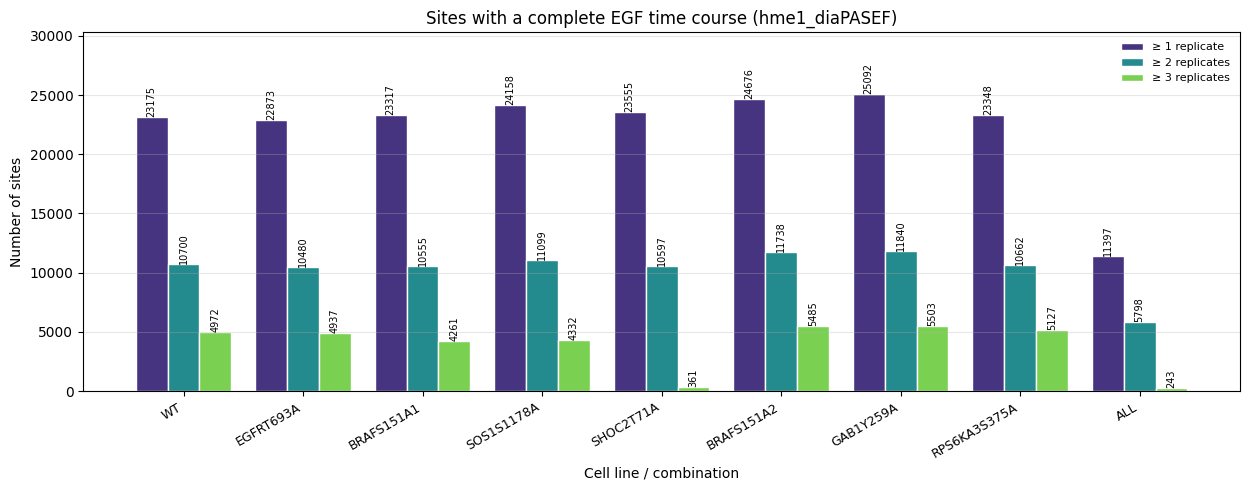

In [6]:
coverage_matrix = replicate_coverage_matrix(to_fabian,
                                            cell_lines=None,
                                            conditions=CONDITION,
                                            data_type=DATA_TYPE,
                                            timepoints=None,
                                            exclude_full=False,
                                            exclude_starve=False,
                                            missing_value=0.0,
                                            site_col= "site")
print(coverage_matrix.shape)
coverage_matrix.head()

GROUPS = {}

# One column per cell line, plus an "ALL" group: sites with a complete time course in every cell line at the same time.
depth = replicate_coverage_depth(counts = coverage_matrix,
                                 groups = None,
                                 include_all=True,) # Returns the coverage per site per cell line.

# For grouping here, you have to define and calculate the groups for the replicate_coverage_depth()
coverage_table = coverage_summary(depth = depth,
                                  max_depth= None,
                                  print_summary = True,)
coverage_df, coverage_fig, ax = plot_replicate_coverage(depth = depth,
                                       max_depth = None,
                                       as_percent= False,
                                       title="Sites with a complete EGF time course (hme1_diaPASEF)",)

#### Union of fully covered sites — ≥ 2 replicates at every timepoint, in at least one cell line

`depth` (cell above) holds, per site and per cell line, the smallest replicate count over that cell line's EGF time course — all 9 timepoints, `full` and `starve` included (`exclude_full=False`, `exclude_starve=False`). A depth of 2 therefore means a complete time course with at least 2 replicates at every timepoint.

The sub-dataset keeps the **union**: a site is kept if *at least one* cell line reaches depth ≥ 2 (`filter_by_coverage(..., group=CELL_LINES, combine="any")`). This is the opposite of the `ALL` column above, which is the **intersection** (complete in all 8 cell lines at once). The union can only be larger than the best single cell line; the intersection can only be smaller than the worst.

⚠️ The kept rows carry the columns of all 8 cell lines, but a site is only guaranteed complete in the cell line(s) that qualified it — elsewhere it can still be sparse. The printed breakdown shows in how many cell lines each kept site is fully covered.

In [8]:
MIN_REPS_SUBSET = 2

# Union over the cell lines: a site is kept if at least ONE cell line has it in >= MIN_REPS_SUBSET replicates at every timepoint.
# "ALL" is left out of `group` on purpose — it is the intersection, not the union.
to_fabian_full2rep = filter_by_coverage(df = to_fabian,
                                        depth = depth,
                                        group = CELL_LINES,
                                        min_reps = MIN_REPS_SUBSET,
                                        combine = "any",
                                        ).copy()

n_qualifying = (depth[CELL_LINES] >= MIN_REPS_SUBSET).sum(axis=1,)
print(f"Union        : {len(to_fabian_full2rep)} of {len(to_fabian)} sites complete with >= {MIN_REPS_SUBSET} reps in at least one cell line")
print(f"Intersection : {int((depth['ALL'] >= MIN_REPS_SUBSET).sum())} sites complete in all {len(CELL_LINES)} cell lines")
print("Number of cell lines in which each kept site is fully covered:")
print(n_qualifying[n_qualifying > 0].value_counts().sort_index().to_string())

# to_fabian_full2rep.to_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260915_batch_corrected_2rep_fullcoverage_union_allcellline_rawabs.tsv", sep="\t", index=False)
to_fabian_full2rep

Union        : 18701 of 71087 sites complete with >= 2 reps in at least one cell line
Intersection : 5798 sites complete in all 8 cell lines
Number of cell lines in which each kept site is fully covered:
1    4036
2    2186
3    1616
4    1291
5    1196
6    1159
7    1419
8    5798


,protein_Id,protein_name,site,peptide_index,WT_raw:abs_EGF_full_r1,WT_raw:abs_EGF_full_r2,WT_raw:abs_EGF_full_r3,WT_raw:abs_EGF_starve_r1,WT_raw:abs_EGF_starve_r2,WT_raw:abs_EGF_starve_r3,...,RPS6KA3S375A_raw:abs_EGF_15_r3,RPS6KA3S375A_raw:abs_EGF_20_r1,RPS6KA3S375A_raw:abs_EGF_20_r2,RPS6KA3S375A_raw:abs_EGF_20_r3,RPS6KA3S375A_raw:abs_EGF_30_r1,RPS6KA3S375A_raw:abs_EGF_30_r2,RPS6KA3S375A_raw:abs_EGF_30_r3,RPS6KA3S375A_raw:abs_EGF_90_r1,RPS6KA3S375A_raw:abs_EGF_90_r2,RPS6KA3S375A_raw:abs_EGF_90_r3
7,Q9H0L4,CSTF2T,Q9H0L4_557_570_1_0~QGGSQPSSFSPGQSQVTPQDQEK,Q9H0L4_557_570_1_0,NaN,NaN,NaN,NaN,NaN,2634.005965,...,NaN,7004.464844,5829.134302,5792.016739,5825.442686,NaN,NaN,NaN,NaN,6383.668715
9,P0DMV8,HSPA1A,P0DMV8_362_371_1_1_S362~DLNKSINPDEAVAYGAAVQAAI...,P0DMV8_362_371_1_1_S362,723.777119,701.257030,440.976100,1011.134042,776.641119,691.623364,...,891.621074,1302.581306,1195.478850,1098.419236,1223.695274,617.704897,794.944331,1479.650173,538.688136,NaN
12,Q96RK0,CIC,Q96RK0_2306_2318_1_1_S2318~NSTDLDSAPEDPTSPKR;R...,Q96RK0_2306_2318_1_1_S2318,2447.295777,1577.979228,1485.400622,18575.409847,19380.992000,9018.375579,...,2281.954541,2445.859942,2264.892956,2679.506648,2321.891461,1901.420869,NaN,3211.371163,5303.124763,2326.936126
18,O15357,INPPL1,O15357_980_1003_1_0~NSFNNPAYYVLEGVPHQLLPPEPPSPAR,O15357_980_1003_1_0,5971.578554,2898.040570,1910.418287,5903.878878,7033.851377,932.889606,...,1790.654505,2268.338817,2268.763858,2152.426375,3033.062756,NaN,2026.875245,NaN,NaN,NaN
24,P35269,GTF2F1,P35269_385_400_1_1_T389~GNSRPGTPSAEGGSTSSTLR,P35269_385_400_1_1_T389,11014.335321,12081.406397,6823.616709,5828.139346,7099.029403,3839.238010,...,4421.529380,4003.352403,4882.191742,2782.146996,2714.155907,3780.562945,2776.510440,2066.084232,4146.829605,1913.081448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71066,Q29RF7,PDS5A,Q29RF7_1223_1233_1_1_S1232~EINSDQATQGNISSDRGK;...,Q29RF7_1223_1233_1_1_S1232,730.939767,889.572767,399.908155,452.581088,702.402121,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,281.360820,NaN,NaN,NaN
71068,Q9HCK8,CHD8,Q9HCK8_1993_2023_2_2_S1995S2008~TASPLPLRPDAPVE...,Q9HCK8_1993_2023_2_2_S1995S2008,10289.639052,6103.912580,3640.018514,12836.976744,10329.503907,5336.697675,...,NaN,4830.038891,4838.697353,5363.712804,7944.964504,6374.675601,5419.266699,6095.055723,5288.109357,4334.553440
71070,P35568,IRS1,P35568_1000_1012_1_1_S1005~QSYVDTSPAAPVSYADMR,P35568_1000_1012_1_1_S1005,2084.642869,1811.323148,685.391206,2041.710945,NaN,795.843489,...,NaN,NaN,NaN,828.663949,1152.360938,NaN,NaN,NaN,584.376279,NaN
71082,Q13112,CHAF1B,Q13112_507_538_1_1_S538~TDTPPSSVPTSVISTPSTEEIQ...,Q13112_507_538_1_1_S538,135745.501401,115784.252066,85170.343698,184149.857557,175530.085338,83415.550481,...,74792.187115,82370.079508,68755.784371,78026.097279,104967.314546,102126.830700,84118.130349,94151.630060,88267.533835,68778.976756
